<a href="https://colab.research.google.com/github/mcjkurz/qhchina/blob/main/tutorials/Novel2Image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install diffusers --upgrade
!pip install invisible_watermark transformers accelerate safetensors scipy ftfy

# Let's download the novella "Love in a Fallen City" by Eileen Chang 张爱玲
!wget https://raw.githubusercontent.com/mcjkurz/qhchina/main/tutorials/data/张爱玲_倾城之恋.txt

--2024-06-17 10:41:29--  https://raw.githubusercontent.com/mcjkurz/qhchina/main/tutorials/data/%E5%BC%A0%E7%88%B1%E7%8E%B2_%E5%80%BE%E5%9F%8E%E4%B9%8B%E6%81%8B.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 86846 (85K) [text/plain]
Saving to: ‘张爱玲_倾城之恋.txt.9’

张爱玲_倾城之恋.txt 100%[===================>]  84.81K  --.-KB/s    in 0.003s  

2024-06-17 10:41:30 (28.8 MB/s) - ‘张爱玲_倾城之恋.txt.9’ saved [86846/86846]



In [ ]:
import torch
from diffusers import StableDiffusionPipeline
torch.backends.cudnn.benchmark = True
pipe = StableDiffusionPipeline.from_pretrained("IDEA-CCNL/Taiyi-Stable-Diffusion-1B-Chinese-v0.1", torch_dtype=torch.float16).to("cuda")

/usr/local/lib/python3.10/dist-packages/diffusers/models/transformers/transformer_2d.py:34: FutureWarning: `Transformer2DModelOutput` is deprecated and will be removed in version 1.0.0. Importing `Transformer2DModelOutput` from `diffusers.models.transformer_2d` is deprecated and this will be removed in a future version. Please use `from diffusers.models.modeling_outputs import Transformer2DModelOutput`, instead.
  deprecate("Transformer2DModelOutput", "1.0.0", deprecation_message)
/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.w

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--IDEA-CCNL--Taiyi-Stable-Diffusion-1B-Chinese-v0.1/snapshots/8de752b2bb2f8a951d16654254a3a46568c8584b/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--IDEA-CCNL--Taiyi-Stable-Diffusion-1B-Chinese-v0.1/snapshots/8de752b2bb2f8a951d16654254a3a46568c8584b/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--IDEA-CCNL--Taiyi-Stable-Diffusion-1B-Chinese-v0.1/snapshots/8de752b2bb2f8a951d16654254a3a46568c8584b/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--IDEA-CCNL--Taiyi-Stable-Diffusion-1B-Chinese-v0.1/snapshots/8de752b2bb2f8a951d16654254a3a46568c8584b/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
We strongly recomm

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

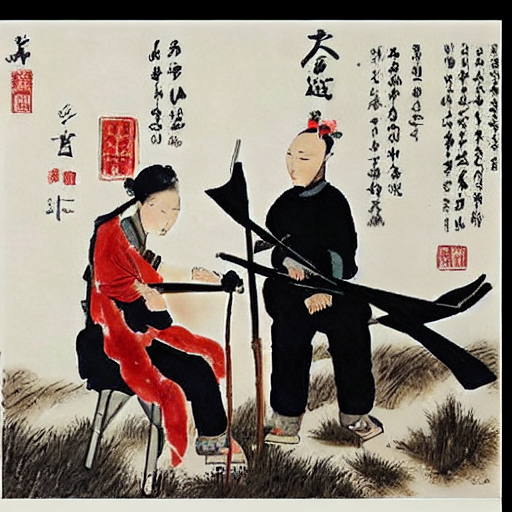

In [ ]:
# generator = torch.Generator("cuda").manual_seed(1023)
# image = pipe(prompt, guidance_scale=7.5, generator=generator).images[0]
prompt = '胡琴，舞场，国画'
image = pipe(prompt, guidance_scale=7.5).images[0]
image.save("飞流.png")
image

  0%|          | 0/50 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


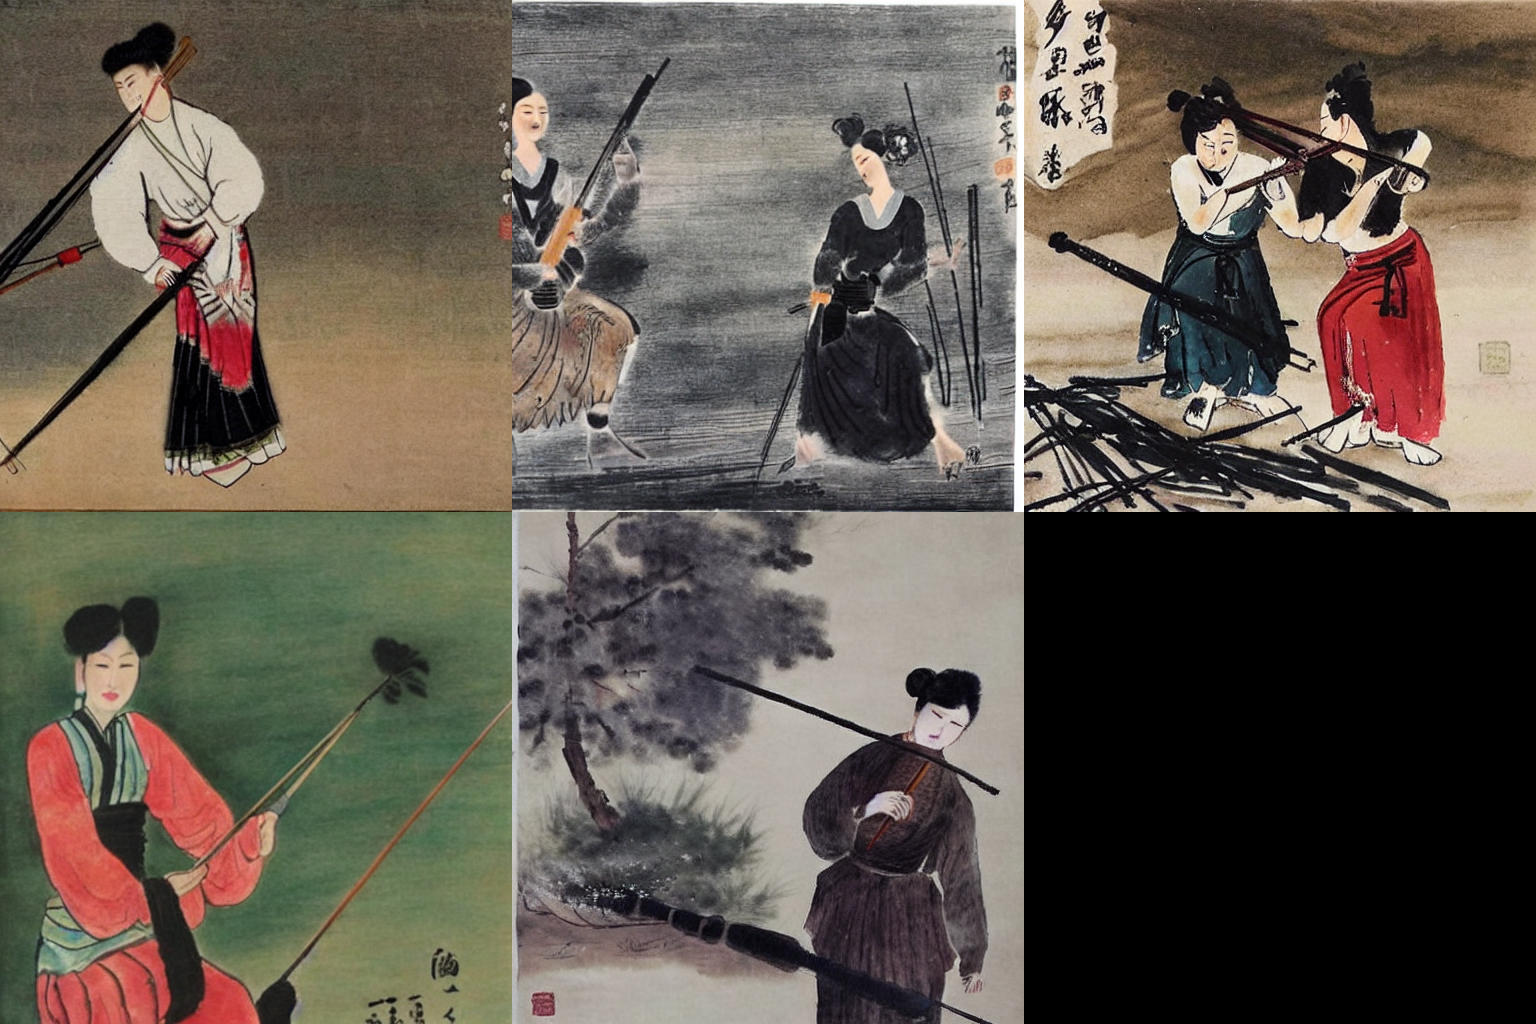

In [ ]:
from PIL import Image

def image_grid(imgs, rows, cols):
    assert len(imgs) == rows*cols

    w, h = imgs[0].size
    grid = Image.new('RGB', size=(cols*w, rows*h))
    grid_w, grid_h = grid.size

    for i, img in enumerate(imgs):
        grid.paste(img, box=(i%cols*w, i//cols*h))
    return grid

num_images = 6
prompt = [prompt] * num_images

images = pipe(prompt).images

grid = image_grid(images, rows=2, cols=3)
grid